# Exploration des données d'une session

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [2]:
boc = BrainObservatoryCache(manifest_file="./data/manifest.json")
dataset = boc.get_ophys_experiment_data(528480613)

Documentation BrainObservatoryNwbDataSet : https://allensdk.readthedocs.io/en/latest/allensdk.core.brain_observatory_nwb_data_set.html#allensdk.core.brain_observatory_nwb_data_set.BrainObservatoryNwbDataSet

## Id des neurones

In [3]:
# np array de tous les ids
cell_ids = dataset.get_cell_specimen_ids()

In [4]:
cell_sample = np.random.choice(cell_ids,10,replace=False)
cell_sample

array([539927700, 539927064, 539926747, 539926723, 539927112, 539927798,
       539927093, 539928185, 539927247, 539927315])

In [5]:
# list des indices de chaque neurone
dataset.get_cell_specimen_indices(cell_sample)

[151, 23, 90, 6, 66, 159, 58, 63, 25, 36]

## Stimulus

In [6]:
# pd DataFrame de tous les types de stimulus et leur début + fin
dataset.get_stimulus_epoch_table()

,stimulus,start,end
0,static_gratings,744,15194
1,natural_scenes,16097,30547
2,spontaneous,30697,39577
3,natural_scenes,39578,54027
4,static_gratings,54930,69379
5,natural_movie_one,70282,79314
6,natural_scenes,80217,96102
7,static_gratings,97381,113635


In [7]:
# pd DataFrame des paramètres de tous les static_gratings
static_gratings = dataset.get_stimulus_table("static_gratings")
static_gratings

,orientation,spatial_frequency,phase,start,end
0,0.0,0.32,0.50,744,751
1,30.0,0.04,0.25,751,758
2,90.0,0.16,0.25,759,766
3,30.0,0.08,0.75,766,773
4,90.0,0.16,0.75,774,781
...,...,...,...,...,...
5995,150.0,0.04,0.00,113598,113605
5996,30.0,0.08,0.00,113606,113613
5997,120.0,0.08,0.25,113613,113620
5998,NaN,NaN,NaN,113621,113628


In [8]:
# pd DataFrame des paramètres de toutes les natural_scenes
natural_scenes = dataset.get_stimulus_table("natural_scenes")
natural_scenes

,frame,start,end
0,50,16097,16104
1,14,16105,16112
2,12,16112,16119
3,44,16120,16127
4,44,16127,16134
...,...,...,...
5945,101,96065,96072
5946,111,96072,96079
5947,74,96080,96087
5948,-1,96087,96094


In [9]:
# np array de toutes les natural_scenes
dataset.get_stimulus_template("natural_scenes").shape

(118, 918, 1174)

## Réponses

In [10]:
timestamps, traces = dataset.get_dff_traces()

In [11]:
# np array des timestamps de tous les fluorescence samples
timestamps.shape

(113861,)

In [12]:
# np array des fluorescence traces de chaque neurone
traces.shape

(184, 113861)

## Raster plots

In [13]:
timestamps, traces = dataset.get_dff_traces()

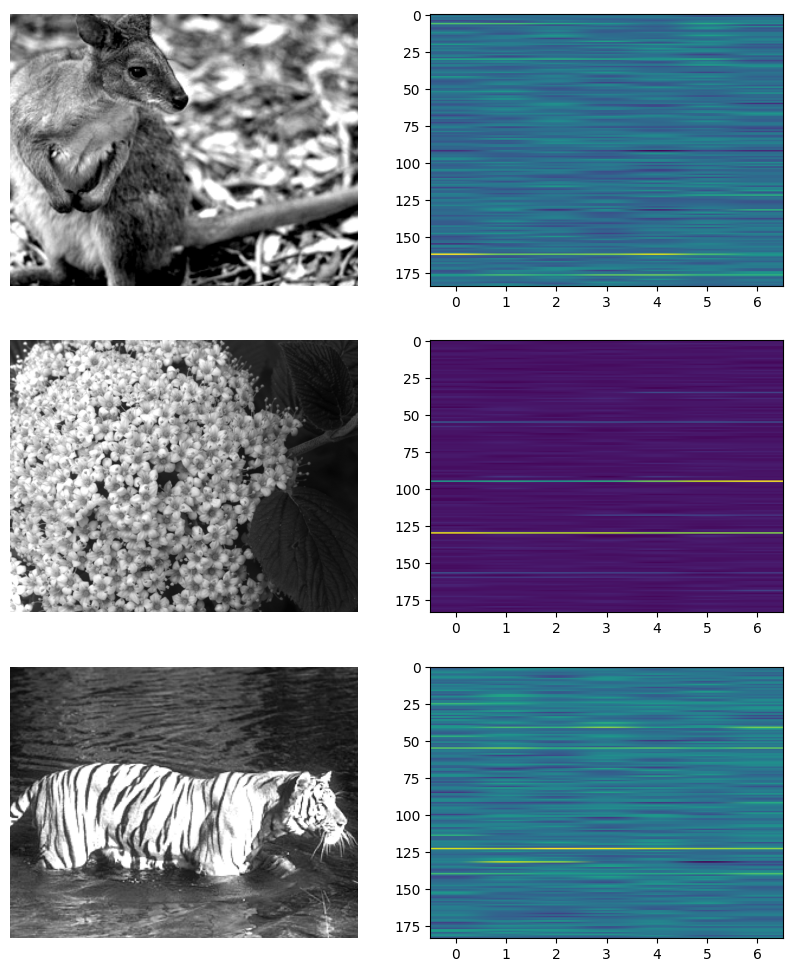

In [14]:
selection = np.random.choice(natural_scenes.index,3,replace=False)
fig, ax = plt.subplots(nrows=3,ncols=2,figsize=(10,12))
for i, choice in enumerate(selection):
    image_id = natural_scenes.loc[choice,"frame"]
    image = dataset.get_stimulus_template("natural_scenes")[image_id]
    presentation_start = natural_scenes.loc[choice,"start"]
    presentation_end = natural_scenes.loc[choice,"end"]
    data = traces[:,presentation_start:presentation_end]
    ax[i,0].imshow(image,cmap="gray")
    ax[i,0].axis("off")
    ax[i,1].imshow(data,aspect="auto")
plt.show()